In [1]:
from pathlib import Path
import urllib.request
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import math
from sklearn.model_selection import train_test_split
from skimage.transform import resize
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

np.random.seed = 42

In [2]:
classes = ["cat", "dog", "car"]
out_dir = Path(r"data\Quick")
out_dir.mkdir(parents=True, exist_ok=True)

for cls in classes:
    url = f"https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/{cls}.npy"
    path = out_dir / f"{cls}.npy"

    if path.exists() and path.stat().st_size > 0:
        print("Уже есть, пропускаю:", path)
        continue

    print("Скачиваю:", cls)
    urllib.request.urlretrieve(url, path)
    print("Готово:", path)

Уже есть, пропускаю: data\Quick\cat.npy
Уже есть, пропускаю: data\Quick\dog.npy
Уже есть, пропускаю: data\Quick\car.npy


In [3]:
def load_quickdraw_npys(data_dir: Path, classes=None, max_per_class=None):
    """
    Загружает per-class .npy файлы из data_dir и возвращает объединённые X, y и список имён классов.

    Args:
        data_dir (Path): директория с файлами формата CLASS.npy.
        classes (list[str] | None): опциональный список имён файлов для загрузки.
            Если None — загружаются все найденные .npy в каталоге.
        max_per_class (int | None): если задано, берётся не более этого числа примеров из каждого файла.

    Returns:
        X (np.ndarray, dtype=uint8): объединённый массив изображений формы (N_total, H, W).
        y (np.ndarray, dtype=int64): вектор меток длины N_total, метки - индексы файлов в порядке files.
        class_names (list[str]): список имён классов (без .npy), порядок соответствует меткам.


    """
    data_dir = Path(data_dir)
    files = sorted([p for p in data_dir.glob('*.npy')])
    if classes is not None:
        files = [data_dir/f'{c}.npy' for c in classes]
    X_list = []
    y_list = []
    class_names = []
    # Для каждого файла загружаем массив
    for idx, f in enumerate(files):
        if not f.exists():
            print('Warning: missing', f)
            continue
        # Загружаем массив
        arr = np.load(f)
        # Преобразуем в (N,H,W)
        N, D = arr.shape
        s = int(math.isqrt(D))
        arr = arr.reshape((N, s, s))
        n = arr.shape[0]
        # Max_per_class обрезает количество
        if max_per_class is not None:
            arr = arr[:max_per_class]
            n = arr.shape[0]
        X_list.append(arr.astype(np.uint8))
        y_list.append(np.full(n, idx, dtype=np.int64))
        class_names.append(f.stem)
    if len(X_list) == 0:
        return np.zeros((0,32,32), dtype=np.uint8), np.array([], dtype=np.int64), []
    X = np.concatenate(X_list, axis=0)
    y = np.concatenate(y_list, axis=0)
    perm = np.random.permutation(len(X))
    return X[perm], y[perm], class_names

In [5]:
data_dir = Path(r"data\Quick")

files = sorted(data_dir.glob("*.npy"))

print("Найдено файлов:", len(files))
print()

for f in files:
    arr = np.load(f)

    print("Файл:", f.name)
    print("  shape:", arr.shape,", dtype:", arr.dtype, ", min:", arr.min(), ", max:", arr.max())    
    print()

X, y, class_names = load_quickdraw_npys(data_dir, max_per_class=500)

print("X shape:", X.shape)
print("X dtype:", X.dtype)
print("X min/max:", X.min(), X.max())
print()

print("y shape:", y.shape)
print("y dtype:", y.dtype)
print("Уникальные метки:", np.unique(y))
print("Количество уникальных меток:", len(np.unique(y)))
print()

print("class_names:", class_names)
print("Количество классов:", len(class_names))

assert len(np.unique(y)) == len(class_names)
assert X.shape[0] == y.shape[0]

Найдено файлов: 3

Файл: car.npy
  shape: (182764, 784) , dtype: uint8 , min: 0 , max: 255

Файл: cat.npy
  shape: (123202, 784) , dtype: uint8 , min: 0 , max: 255

Файл: dog.npy
  shape: (152159, 784) , dtype: uint8 , min: 0 , max: 255

X shape: (1500, 28, 28)
X dtype: uint8
X min/max: 0 255

y shape: (1500,)
y dtype: int64
Уникальные метки: [0 1 2]
Количество уникальных меток: 3

class_names: ['car', 'cat', 'dog']
Количество классов: 3


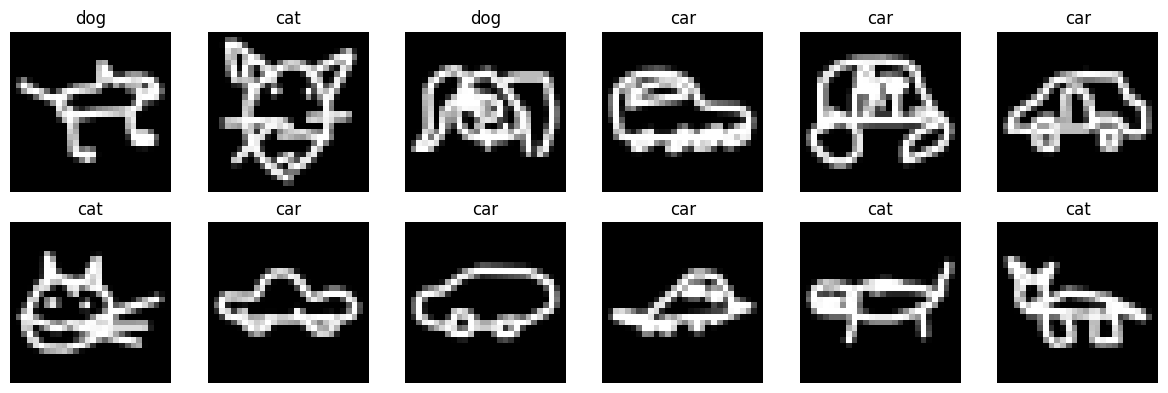

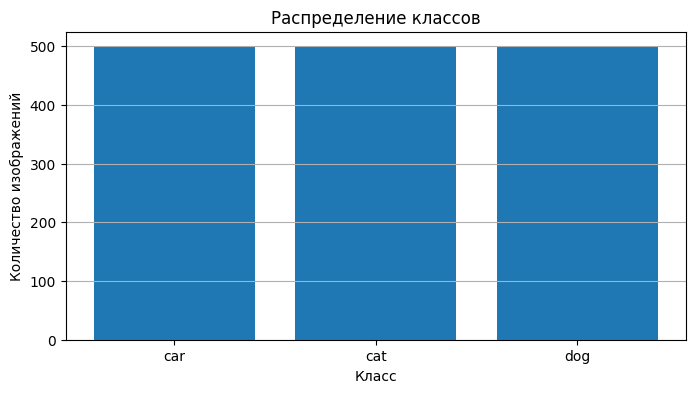

In [6]:
n_examples = min(12, len(X))

plt.figure(figsize=(12, 4))

for i in range(n_examples):
    plt.subplot(2, 6, i + 1)
    plt.imshow(X[i], cmap="gray")
    plt.title(class_names[y[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()


counts = np.bincount(y, minlength=len(class_names))

plt.figure(figsize=(8, 4))
plt.bar(class_names, counts)
plt.xlabel("Класс")
plt.ylabel("Количество изображений")
plt.title("Распределение классов")
plt.grid(axis="y")
plt.show()

X_train: (1049, 32, 32) float32 0.0 1.0
X_val:   (226, 32, 32) float32 0.0 1.0
X_test:  (225, 32, 32) float32 0.0 1.0
y_train: (1049,) [0 1 2]
y_val:   (226,) [0 1 2]
y_test:  (225,) [0 1 2]


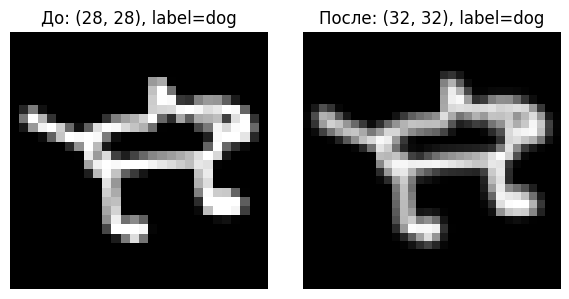

До:
  shape: (28, 28)
  dtype: uint8
  min/max: 0 255
После:
  shape: (32, 32)
  dtype: float32
  min/max: 0.0 1.0


In [7]:
SEED = 42

def preprocess_images(X, target_size=(32, 32)):
    X_processed = []

    for img in X:
        img_resized = resize(
            img,
            target_size,
            anti_aliasing=True,
            preserve_range=True
        )

        img_normalized = img_resized.astype(np.float32) / 255.0
        X_processed.append(img_normalized)

    return np.stack(X_processed, axis=0)


X_processed = preprocess_images(X, target_size=(32, 32))

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_processed,
    y,
    test_size=0.15,
    random_state=SEED,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.1765,
    random_state=SEED,
    stratify=y_train_val
)


print("X_train:", X_train.shape, X_train.dtype, X_train.min(), X_train.max())
print("X_val:  ", X_val.shape, X_val.dtype, X_val.min(), X_val.max())
print("X_test: ", X_test.shape, X_test.dtype, X_test.min(), X_test.max())

print("y_train:", y_train.shape, np.unique(y_train))
print("y_val:  ", y_val.shape, np.unique(y_val))
print("y_test: ", y_test.shape, np.unique(y_test))


idx = 0

plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.imshow(X[idx], cmap="gray")
plt.title(f"До: {X[idx].shape}, label={class_names[y[idx]]}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(X_processed[idx], cmap="gray")
plt.title(f"После: {X_processed[idx].shape}, label={class_names[y[idx]]}")
plt.axis("off")

plt.tight_layout()
plt.show()

print("До:")
print("  shape:", X[idx].shape)
print("  dtype:", X[idx].dtype)
print("  min/max:", X[idx].min(), X[idx].max())

print("После:")
print("  shape:", X_processed[idx].shape)
print("  dtype:", X_processed[idx].dtype)
print("  min/max:", X_processed[idx].min(), X_processed[idx].max())

In [8]:
class NumpyMLP:
    def __init__(
        self,
        layer_sizes,
        activation="relu",
        init="auto",
        lr=0.001,
        seed=42
    ):
        self.layer_sizes = layer_sizes
        self.activation = activation
        self.init = init
        self.lr = lr
        self.rng = np.random.default_rng(seed)

        self.W = []
        self.b = []

        self.Z = []
        self.A = []

        self.dW = []
        self.db = []

        self.mW = []
        self.vW = []
        self.mb = []
        self.vb = []
        self.t = 0

        self._init_weights()
        self._init_adam_state()

    def _init_weights(self):
        for i in range(len(self.layer_sizes) - 1):
            fan_in = self.layer_sizes[i]
            fan_out = self.layer_sizes[i + 1]

            if self.init == "he" or (self.init == "auto" and self.activation == "relu"):
                scale = np.sqrt(2.0 / fan_in)
            elif self.init == "xavier" or (self.init == "auto" and self.activation == "tanh"):
                scale = np.sqrt(1.0 / fan_in)
            else:
                scale = 0.01

            W = self.rng.normal(0, scale, size=(fan_in, fan_out)).astype(np.float32)
            b = np.zeros((1, fan_out), dtype=np.float32)

            self.W.append(W)
            self.b.append(b)

    def _init_adam_state(self):
        self.mW = [np.zeros_like(W) for W in self.W]
        self.vW = [np.zeros_like(W) for W in self.W]
        self.mb = [np.zeros_like(b) for b in self.b]
        self.vb = [np.zeros_like(b) for b in self.b]
        self.t = 0

    def _activate(self, Z):
        if self.activation == "relu":
            return np.maximum(0, Z)
        if self.activation == "tanh":
            return np.tanh(Z)
        raise ValueError(f"Unknown activation: {self.activation}")

    def _dactivate(self, Z):
        if self.activation == "relu":
            return (Z > 0).astype(np.float32)
        if self.activation == "tanh":
            return 1.0 - np.tanh(Z) ** 2
        raise ValueError(f"Unknown activation: {self.activation}")

    def forward(self, X):
        self.Z = []
        self.A = [X]

        A = X

        for i in range(len(self.W)):
            Z = A @ self.W[i] + self.b[i]
            self.Z.append(Z)

            if i < len(self.W) - 1:
                A = self._activate(Z)
            else:
                A = Z

            self.A.append(A)

        return A

    def softmax_cross_entropy(self, logits, y):
        logits_stable = logits - np.max(logits, axis=1, keepdims=True)

        exp_logits = np.exp(logits_stable)
        probs = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

        n = y.shape[0]
        loss = -np.mean(np.log(probs[np.arange(n), y] + 1e-12))

        return loss, probs

    def backward(self, y):
        n = y.shape[0]

        logits = self.A[-1]
        loss, probs = self.softmax_cross_entropy(logits, y)

        delta = probs.copy()
        delta[np.arange(n), y] -= 1
        delta /= n

        self.dW = [None] * len(self.W)
        self.db = [None] * len(self.b)

        for i in range(len(self.W) - 1, -1, -1):
            A_prev = self.A[i]

            self.dW[i] = A_prev.T @ delta
            self.db[i] = np.sum(delta, axis=0, keepdims=True)

            if i > 0:
                delta = delta @ self.W[i].T
                delta *= self._dactivate(self.Z[i - 1])

        return loss

    def step_sgd(self):
        for i in range(len(self.W)):
            self.W[i] -= self.lr * self.dW[i]
            self.b[i] -= self.lr * self.db[i]

    def step_adam(self, beta1=0.9, beta2=0.999, eps=1e-8):
        self.t += 1

        for i in range(len(self.W)):
            self.mW[i] = beta1 * self.mW[i] + (1 - beta1) * self.dW[i]
            self.vW[i] = beta2 * self.vW[i] + (1 - beta2) * (self.dW[i] ** 2)

            self.mb[i] = beta1 * self.mb[i] + (1 - beta1) * self.db[i]
            self.vb[i] = beta2 * self.vb[i] + (1 - beta2) * (self.db[i] ** 2)

            mW_hat = self.mW[i] / (1 - beta1 ** self.t)
            vW_hat = self.vW[i] / (1 - beta2 ** self.t)

            mb_hat = self.mb[i] / (1 - beta1 ** self.t)
            vb_hat = self.vb[i] / (1 - beta2 ** self.t)

            self.W[i] -= self.lr * mW_hat / (np.sqrt(vW_hat) + eps)
            self.b[i] -= self.lr * mb_hat / (np.sqrt(vb_hat) + eps)

    def predict(self, X):
        logits = self.forward(X)
        return np.argmax(logits, axis=1)

    def accuracy(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

    def evaluate(self, X, y):
        logits = self.forward(X)
        loss, _ = self.softmax_cross_entropy(logits, y)
        acc = np.mean(np.argmax(logits, axis=1) == y)
        return loss, acc

    def save(self, path):
        path = Path(path)

        data = {
            "layer_sizes": np.array(self.layer_sizes),
            "activation": np.array(self.activation),
            "init": np.array(self.init),
            "lr": np.array(self.lr),
            "t": np.array(self.t),
        }

        for i, W in enumerate(self.W):
            data[f"W_{i}"] = W
            data[f"b_{i}"] = self.b[i]
            data[f"mW_{i}"] = self.mW[i]
            data[f"vW_{i}"] = self.vW[i]
            data[f"mb_{i}"] = self.mb[i]
            data[f"vb_{i}"] = self.vb[i]

        np.savez(path, **data)

    @classmethod
    def load(cls, path):
        path = Path(path)
        data = np.load(path, allow_pickle=True)

        layer_sizes = data["layer_sizes"].astype(int).tolist()
        activation = str(data["activation"])
        init = str(data["init"])
        lr = float(data["lr"])

        model = cls(
            layer_sizes=layer_sizes,
            activation=activation,
            init=init,
            lr=lr
        )

        for i in range(len(model.W)):
            model.W[i] = data[f"W_{i}"]
            model.b[i] = data[f"b_{i}"]
            model.mW[i] = data[f"mW_{i}"]
            model.vW[i] = data[f"vW_{i}"]
            model.mb[i] = data[f"mb_{i}"]
            model.vb[i] = data[f"vb_{i}"]

        model.t = int(data["t"])

        return model

In [9]:
# подготовка данных под MLP

X_train_mlp = X_train.reshape(X_train.shape[0], -1).astype(np.float32)
X_val_mlp = X_val.reshape(X_val.shape[0], -1).astype(np.float32)
X_test_mlp = X_test.reshape(X_test.shape[0], -1).astype(np.float32)

y_train_mlp = y_train.astype(np.int64)
y_val_mlp = y_val.astype(np.int64)
y_test_mlp = y_test.astype(np.int64)

input_dim = X_train_mlp.shape[1]
output_dim = len(class_names)

print("input_dim:", input_dim)
print("output_dim:", output_dim)

print("X_train_mlp:", X_train_mlp.shape, X_train_mlp.dtype)
print("X_val_mlp:  ", X_val_mlp.shape, X_val_mlp.dtype)
print("X_test_mlp: ", X_test_mlp.shape, X_test_mlp.dtype)

input_dim: 1024
output_dim: 3
X_train_mlp: (1049, 1024) float32
X_val_mlp:   (226, 1024) float32
X_test_mlp:  (225, 1024) float32


In [10]:
# train loop

def iterate_minibatches(X, y, batch_size=64, shuffle=True, seed=42):
    rng = np.random.default_rng(seed)

    indices = np.arange(len(X))

    if shuffle:
        rng.shuffle(indices)

    for start in range(0, len(X), batch_size):
        batch_idx = indices[start:start + batch_size]
        yield X[batch_idx], y[batch_idx]


def train_numpy_mlp(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=50,
    batch_size=64,
    optimizer="adam",
    seed=42
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": [],
        "epoch_time": []
    }

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        train_losses = []

        for X_batch, y_batch in iterate_minibatches(
            X_train,
            y_train,
            batch_size=batch_size,
            shuffle=True,
            seed=seed + epoch
        ):
            model.forward(X_batch)
            batch_loss = model.backward(y_batch)

            if optimizer == "sgd":
                model.step_sgd()
            elif optimizer == "adam":
                model.step_adam()
            else:
                raise ValueError(f"Unknown optimizer: {optimizer}")

            train_losses.append(batch_loss)

        val_loss, val_acc = model.evaluate(X_val, y_val)
        epoch_time = time.time() - t0

        history["train_loss"].append(float(np.mean(train_losses)))
        history["val_loss"].append(float(val_loss))
        history["val_acc"].append(float(val_acc))
        history["epoch_time"].append(float(epoch_time))

        print(
            f"Epoch {epoch:03d}/{epochs} | "
            f"train_loss={history['train_loss'][-1]:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_acc={val_acc:.4f} | "
            f"time={epoch_time:.2f}s"
        )

    return history

In [11]:
# Обучение модели

model = NumpyMLP(
    layer_sizes=[input_dim, 256, 128, output_dim],
    activation="relu",
    init="he",
    lr=0.001,
    seed=42
)

history = train_numpy_mlp(
    model,
    X_train_mlp,
    y_train_mlp,
    X_val_mlp,
    y_val_mlp,
    epochs=50,
    batch_size=64,
    optimizer="adam",
    seed=42
)

Epoch 001/50 | train_loss=0.7429 | val_loss=0.6797 | val_acc=0.7168 | time=0.12s
Epoch 002/50 | train_loss=0.5126 | val_loss=0.5884 | val_acc=0.7522 | time=0.12s
Epoch 003/50 | train_loss=0.3795 | val_loss=0.5922 | val_acc=0.7699 | time=0.12s
Epoch 004/50 | train_loss=0.3001 | val_loss=0.5680 | val_acc=0.7389 | time=0.13s
Epoch 005/50 | train_loss=0.2540 | val_loss=0.5975 | val_acc=0.7699 | time=0.16s
Epoch 006/50 | train_loss=0.1894 | val_loss=0.5927 | val_acc=0.7788 | time=0.13s
Epoch 007/50 | train_loss=0.1354 | val_loss=0.6091 | val_acc=0.7699 | time=0.13s
Epoch 008/50 | train_loss=0.1003 | val_loss=0.6544 | val_acc=0.7389 | time=0.22s
Epoch 009/50 | train_loss=0.0663 | val_loss=0.6821 | val_acc=0.7788 | time=0.13s
Epoch 010/50 | train_loss=0.0469 | val_loss=0.6451 | val_acc=0.7655 | time=0.15s
Epoch 011/50 | train_loss=0.0318 | val_loss=0.7029 | val_acc=0.7522 | time=0.11s
Epoch 012/50 | train_loss=0.0217 | val_loss=0.7376 | val_acc=0.7699 | time=0.14s
Epoch 013/50 | train_loss=0.

In [12]:
# проверка на тесте и сохранение

test_loss, test_acc = model.evaluate(X_test_mlp, y_test_mlp)

print("test_loss:", test_loss)
print("test_acc:", test_acc)

model.save("numpy_mlp_quickdraw.npz")

test_loss: 1.1540554
test_acc: 0.7866666666666666


In [13]:
loaded_model = NumpyMLP.load("numpy_mlp_quickdraw.npz")

loaded_test_loss, loaded_test_acc = loaded_model.evaluate(X_test_mlp, y_test_mlp)

print("loaded_test_loss:", loaded_test_loss)
print("loaded_test_acc:", loaded_test_acc)

loaded_test_loss: 1.1540554
loaded_test_acc: 0.7866666666666666


In [14]:
# TorchMLP
SEED = 42

torch.manual_seed(SEED)

class TorchMLP(nn.Module):
    def __init__(self, layer_sizes, activation="relu", init="he"):
        super().__init__()

        self.layer_sizes = layer_sizes
        self.activation_name = activation
        self.init = init

        layers = []

        for i in range(len(layer_sizes) - 1):
            layers.append(nn.Linear(layer_sizes[i], layer_sizes[i + 1]))            

        self.layers = nn.ModuleList(layers)
        self.dropuot = nn.Dropout(0.5)
        
        self.activation = self._get_activation()
        self._init_weights()

    def _get_activation(self):
        if self.activation_name == "relu":
            return nn.ReLU()
        if self.activation_name == "tanh":
            return nn.Tanh()
        raise ValueError(f"Unknown activation: {self.activation_name}")

    def _init_weights(self):
        for layer in self.layers:
            if self.init == "he":
                nn.init.kaiming_normal_(layer.weight, nonlinearity="relu")
            elif self.init == "xavier":
                nn.init.xavier_normal_(layer.weight)
            else:
                raise ValueError(f"Unknown init: {self.init}")

            nn.init.zeros_(layer.bias)

    def forward(self, x):
        x = x.view(x.size(0), -1)

        for i, layer in enumerate(self.layers):
            x = layer(x)

            if i < len(self.layers) - 1:
                x = self.activation(x)
                x = self.dropuot(x) #####################################

        return x

In [15]:
# dataset и dataloader
class QuickDrawDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


batch_size = 64

train_dataset = QuickDrawDataset(X_train, y_train)
val_dataset = QuickDrawDataset(X_val, y_val)
test_dataset = QuickDrawDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [16]:
# train val loop

def evaluate_torch(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_count = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            preds = torch.argmax(logits, dim=1)

            total_loss += loss.item() * X_batch.size(0)
            total_correct += (preds == y_batch).sum().item()
            total_count += X_batch.size(0)

    avg_loss = total_loss / total_count
    avg_acc = total_correct / total_count

    return avg_loss, avg_acc


def train_torch_mlp(
    model,
    train_loader,
    val_loader,
    epochs=50,
    lr=0.001,
    optimizer_name="adam",
    device=None
):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == "adamw":
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "epoch_time": []
    }

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        model.train()

        total_loss = 0.0
        total_correct = 0
        total_count = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            loss.backward()
            optimizer.step()

            preds = torch.argmax(logits, dim=1)

            total_loss += loss.item() * X_batch.size(0)
            total_correct += (preds == y_batch).sum().item()
            total_count += X_batch.size(0)

        train_loss = total_loss / total_count
        train_acc = total_correct / total_count

        val_loss, val_acc = evaluate_torch(model, val_loader, criterion, device)

        epoch_time = time.time() - t0

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["epoch_time"].append(epoch_time)

        print(
            f"Epoch {epoch:03d}/{epochs} | "
            f"train_loss={train_loss:.4f} | "
            f"train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_acc={val_acc:.4f} | "
            f"time={epoch_time:.2f}s"
        )

    return history

Epoch 001/50 | train_loss=1.1077 | train_acc=0.3994 | val_loss=0.9185 | val_acc=0.5841 | time=0.07s
Epoch 002/50 | train_loss=0.9314 | train_acc=0.5272 | val_loss=0.8050 | val_acc=0.6062 | time=0.06s
Epoch 003/50 | train_loss=0.8174 | train_acc=0.6263 | val_loss=0.7395 | val_acc=0.6770 | time=0.05s
Epoch 004/50 | train_loss=0.7664 | train_acc=0.6492 | val_loss=0.6803 | val_acc=0.6991 | time=0.07s
Epoch 005/50 | train_loss=0.7160 | train_acc=0.6454 | val_loss=0.6675 | val_acc=0.6858 | time=0.05s
Epoch 006/50 | train_loss=0.7028 | train_acc=0.6883 | val_loss=0.6533 | val_acc=0.6991 | time=0.05s
Epoch 007/50 | train_loss=0.6592 | train_acc=0.7131 | val_loss=0.6140 | val_acc=0.7212 | time=0.04s
Epoch 008/50 | train_loss=0.6306 | train_acc=0.7226 | val_loss=0.6207 | val_acc=0.7124 | time=0.05s
Epoch 009/50 | train_loss=0.6142 | train_acc=0.7245 | val_loss=0.5919 | val_acc=0.7301 | time=0.05s
Epoch 010/50 | train_loss=0.5753 | train_acc=0.7493 | val_loss=0.6059 | val_acc=0.7124 | time=0.04s


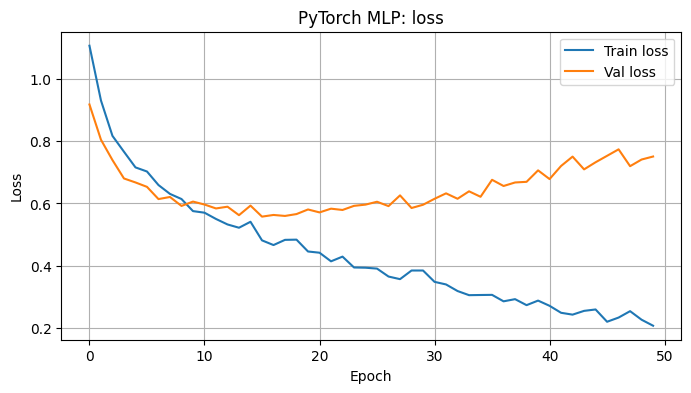

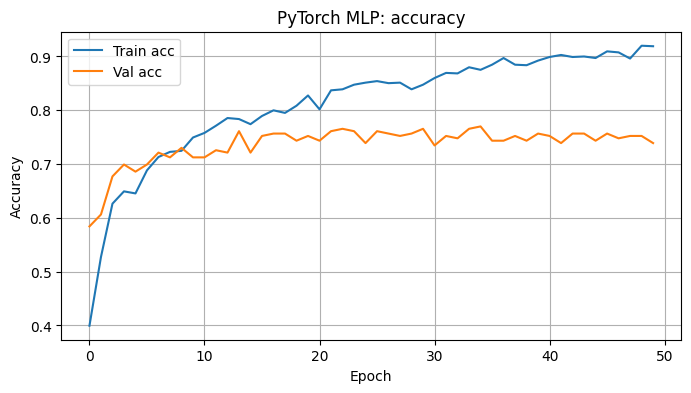

In [17]:
# Запуск обучения

input_dim = 32 * 32
output_dim = len(class_names)

#torch_model = TorchMLP(
 #   layer_sizes=[input_dim, 256, 128, output_dim],
   # activation="tanh",
    #init="xavier"
#)

torch_model = TorchMLP(
    layer_sizes=[input_dim, 64, 32, output_dim],
    activation="relu",    
    init="he"
)

torch_history = train_torch_mlp(
    torch_model,
    train_loader,
    val_loader,
    epochs=50,
    lr=0.001,
    optimizer_name="adam"
)

plt.figure(figsize=(8, 4))
plt.plot(torch_history["train_loss"], label="Train loss")
plt.plot(torch_history["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PyTorch MLP: loss")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 4))
plt.plot(torch_history["train_acc"], label="Train acc")
plt.plot(torch_history["val_acc"], label="Val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("PyTorch MLP: accuracy")
plt.legend()
plt.grid(True)
plt.show()

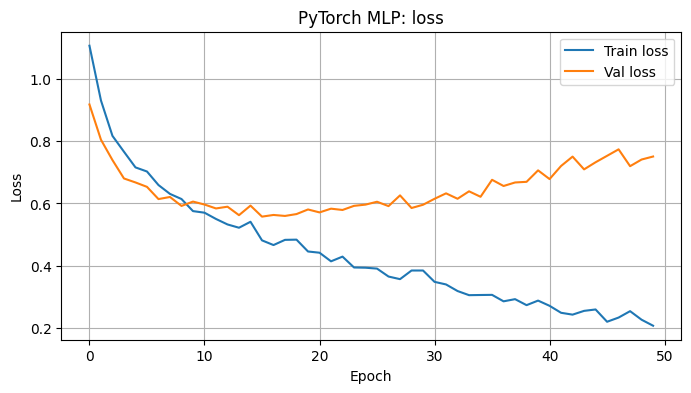

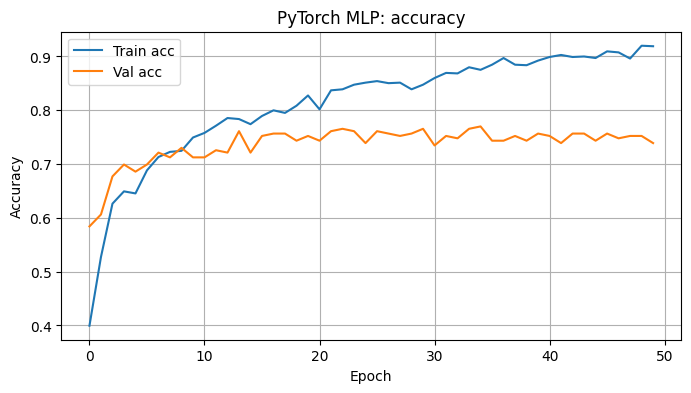

In [18]:
# Графики

plt.figure(figsize=(8, 4))
plt.plot(torch_history["train_loss"], label="Train loss")
plt.plot(torch_history["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PyTorch MLP: loss")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 4))
plt.plot(torch_history["train_acc"], label="Train acc")
plt.plot(torch_history["val_acc"], label="Val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("PyTorch MLP: accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
# Тест

device = "cuda" if torch.cuda.is_available() else "cpu"
criterion = nn.CrossEntropyLoss()

test_loss, test_acc = evaluate_torch(
    torch_model.to(device),
    test_loader,
    criterion,
    device
)

print("test_loss:", test_loss)
print("test_acc:", test_acc)

test_loss: 0.8151584800084432
test_acc: 0.7466666666666667


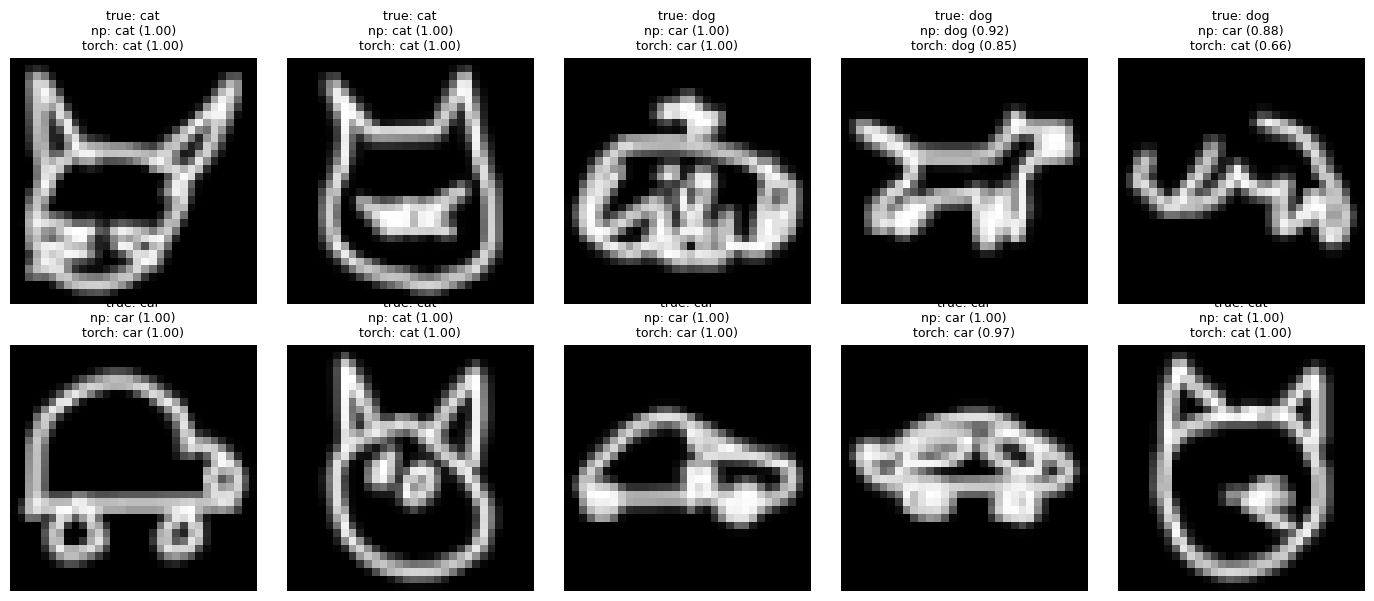

Ошибок среди показанных примеров: 2

idx=139 | true=dog | numpy=car (1.000) | torch=car (1.000)
idx=133 | true=dog | numpy=car (0.877) | torch=cat (0.660)
NumPy test_loss: 1.1540554
NumPy test_acc:  0.7866666666666666

PyTorch test_loss: 0.8151584800084432
PyTorch test_acc:  0.7466666666666667


In [20]:
# Инференс

def predict_numpy(model, x):
    """
    Предсказывает класс одной картинки через NumPy-модель.

    x: изображение формы (32, 32) или вектор (1024,)
    return: predicted_class, probability
    """
    x_flat = x.reshape(1, -1).astype(np.float32)

    logits = model.forward(x_flat)
    _, probs = model.softmax_cross_entropy(logits, np.array([0]))  # y здесь нужен только для вызова функции

    pred = int(np.argmax(probs, axis=1)[0])
    prob = float(probs[0, pred])

    return pred, prob


def predict_torch(model, x, device=None):
    """
    Предсказывает класс одной картинки через PyTorch-модель.

    x: изображение формы (32, 32) или вектор (1024,)
    return: predicted_class, probability
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    model.eval()
    model.to(device)

    x_tensor = torch.tensor(x, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x_tensor)
        probs = torch.softmax(logits, dim=1)

    pred = int(torch.argmax(probs, dim=1).item())
    prob = float(probs[0, pred].item())

    return pred, prob


n_examples = 10

indices = np.random.choice(len(X_test), size=n_examples, replace=False)

plt.figure(figsize=(14, 6))

errors = []

for i, idx in enumerate(indices):
    x = X_test[idx]
    true_label = int(y_test[idx])

    pred_np, prob_np = predict_numpy(model, x)
    pred_torch, prob_torch = predict_torch(torch_model, x)

    is_error = pred_torch != true_label

    if is_error:
        errors.append({
            "idx": idx,
            "true": class_names[true_label],
            "numpy_pred": class_names[pred_np],
            "numpy_prob": prob_np,
            "torch_pred": class_names[pred_torch],
            "torch_prob": prob_torch,
        })

    plt.subplot(2, 5, i + 1)
    plt.imshow(x, cmap="gray")

    title = (
        f"true: {class_names[true_label]}\n"
        f"np: {class_names[pred_np]} ({prob_np:.2f})\n"
        f"torch: {class_names[pred_torch]} ({prob_torch:.2f})"
    )

    plt.title(title, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

print("Ошибок среди показанных примеров:", len(errors))
print()

for e in errors:
    print(
        f"idx={e['idx']} | "
        f"true={e['true']} | "
        f"numpy={e['numpy_pred']} ({e['numpy_prob']:.3f}) | "
        f"torch={e['torch_pred']} ({e['torch_prob']:.3f})"
    )

numpy_test_loss, numpy_test_acc = model.evaluate(X_test_mlp, y_test_mlp)

device = "cuda" if torch.cuda.is_available() else "cpu"
criterion = torch.nn.CrossEntropyLoss()

torch_test_loss, torch_test_acc = evaluate_torch(
    torch_model.to(device),
    test_loader,
    criterion,
    device
)

print("NumPy test_loss:", numpy_test_loss)
print("NumPy test_acc: ", numpy_test_acc)
print()
print("PyTorch test_loss:", torch_test_loss)
print("PyTorch test_acc: ", torch_test_acc)